In [222]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import Circular_Kalman_Filter
import Baysian_Ring_Attractor

np.random.seed(42)

## Set up HD and dy inputs

Stationary HD input:

In [223]:
def generate_HD_static(T, dt, angle):

    steps = int(T / dt)
    z = np.full(steps, angle)
    dy = np.zeros(steps)

    return z, dy

In [224]:
def generate_HD_rotate(T,dt, angle, d_angle):
    steps = int(T / dt)
    z = np.full(steps, angle)
    for i in range(steps):
        z[i] = ((z[i] + d_angle * i) + np.pi) % (2 * np.pi) - np.pi

    dy = np.full(steps, d_angle)

    return z, dy


In [225]:
def generate_HD_random(T,dt, angle,d_angle):
    steps = int(T / dt)
    z = np.zeros(steps)
    z[0] = angle
    dy = np.zeros(steps)
    for i in range(1, steps):
        factor = np.random.randint(-5,5)
        d_angle_step = factor * d_angle
        z[i] = ((z[i-1] + d_angle_step) + np.pi) % (2 * np.pi) - np.pi
        dy[i] = d_angle_step

    return z, dy

## Kalman filter run

In [226]:
def run_circKF(kappa_phi, dt, k_z, k_v, z, dy):

    steps = len(z)

    ckf = Circular_Kalman_Filter.CKF(kappa_phi, dt, k_z, k_v)


    for i in range(steps):
        ckf.kalman_step(
            z=z[i], dy=dy[i], k_z=k_z,
            k_v=k_v
        )

    return ckf.mu, ckf.kappa

## RNN filter run

In [227]:
def run_RNN(dt, tau, k_phi, k_v, k_z, w_const, w_quad, z, dy):
    steps = len(z)
    N = 30

    rnn = Baysian_Ring_Attractor.Ring_Attractor(
        N, dt, tau, k_phi, k_v, k_z, w_const, w_quad,
        kappa_0=1, phi_0=0,stoch_corr=0
    )

    for i in range(steps):
        rnn.RNN_step(dy=dy[i], z=z[i])

    return rnn.mu, rnn.kappa, rnn.r

## Analysis helpers

In [228]:
def circular_error(estimate, true_val):
    """Circular distance between estimate and true value."""

    diff = estimate - true_val
    return np.abs((diff + np.pi) % (2*np.pi) - np.pi)

def compute_error(mu, kappa, z):
    lock_on_error = np.mean(circular_error(mu[1:], z[:]))

    # Final certainty
    final_kappa = kappa[-1]

    return {
        'lock_on_error': lock_on_error,
        'final_kappa': final_kappa
    }

## 5. Parameter Sweep config

In [229]:
# Parameter ranges
param_ranges = {
    'circKF': {
        'k_phi': [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0],
        'k_z': [0.2, 0.5, 1.0, 3.0, 5.0, 10.0, 20.0],
        'k_v': [0.2, 0.5, 1.0, 3.0, 5.0, 10.0, 20.0]
    },
    'RNN': {
        'tau': [1.0],
        'k_z': [0.5, 1.0, 2.0, 10.],
        'k_v': [0.5, 1.0, 2.0, 10.],
        'k_phi': [0.1, 0.5, 1.0, 10.0],
        'w_const': [0.0, 5.0],
        'w_quad': [0.1, 0.5, 1.0, 2.0]
    }
}

# Simulation settings
T = 2.0  # total time
dt = 1/30
angle = np.pi/2


print(f"Parameter sweep configuration:")
print(f"  circKF combinations: {np.prod([len(v) for v in param_ranges['circKF'].values()])}")
print(f"  RNN combinations: {np.prod([len(v) for v in param_ranges['RNN'].values()])}")

print(f"  Total runs: {(np.prod([len(v) for v in param_ranges['circKF'].values()]) + np.prod([len(v) for v in param_ranges['RNN'].values()]))}")

Parameter sweep configuration:
  circKF combinations: 343
  RNN combinations: 512
  Total runs: 855


## Run parameter sweep

In [230]:
from collections import defaultdict

# Storage for results
results_circKF = defaultdict(list)
results_RNN = defaultdict(list)

z, dy = generate_HD_random(T, dt, angle, np.pi/24)
print(z,dy)

circKF_params = list(product(
    param_ranges['circKF']['k_phi'],
    param_ranges['circKF']['k_z'],
    param_ranges['circKF']['k_v']
))

for pidx, (k_phi, k_z, k_v) in enumerate(circKF_params):
    try:
        mu, kappa = run_circKF(k_phi, dt, k_z, k_v, z, dy)
        error = compute_error(mu, kappa, z)

        param_key = (k_phi, k_z, k_v)
        results_circKF[param_key].append({
            'mu': mu,
            'kappa': kappa,
            'error': error
        })

    except Exception as e:
        print(f"  Error at params {(k_phi, k_z, k_v)}: {e}")

[ 1.57079633  1.70169602  1.43989663  1.70169602  1.57079633  1.70169602
  2.2252948   1.83259571  1.96349541  2.2252948   2.0943951   1.83259571
  2.0943951   2.35619449  1.96349541  1.96349541  1.83259571  1.30899694
  1.57079633  1.57079633  1.04719755  0.91629786  0.26179939  0.78539816
  0.78539816  1.17809725  0.52359878  1.04719755  0.65449847  0.78539816
  0.52359878  0.91629786  0.52359878  0.39269908  0.          0.13089969
  0.          0.39269908  0.52359878  0.         -0.26179939  0.13089969
 -0.39269908  0.13089969  0.52359878  1.04719755  0.91629786  0.39269908
  0.13089969  0.26179939  0.52359878  0.13089969 -0.52359878 -0.78539816
 -1.30899694 -1.04719755 -1.30899694 -1.83259571 -1.83259571 -1.83259571] [ 0.          0.13089969 -0.26179939  0.26179939 -0.13089969  0.13089969
  0.52359878 -0.39269908  0.13089969  0.26179939 -0.13089969 -0.26179939
  0.26179939  0.26179939 -0.39269908  0.         -0.13089969 -0.52359878
  0.26179939  0.         -0.52359878 -0.13089969 -

In [231]:
RNN_params = list(product(
    param_ranges['RNN']['tau'],
    param_ranges['RNN']['k_z'],
    param_ranges['RNN']['k_v'],
    param_ranges['RNN']['k_phi'],
    param_ranges['RNN']['w_const'],
    param_ranges['RNN']['w_quad']
))


for pidx, (tau, k_z, k_v, k_phi, w_const, w_quad) in enumerate(RNN_params):

    try:
        mu, kappa, r = run_RNN(dt, tau, k_phi, k_v, k_z, w_const, w_quad, z, dy)
        error = compute_error(mu, kappa, z)
        param_key = (tau, k_z, k_v, k_phi, w_const, w_quad)
        results_RNN[param_key].append({
            'mu': np.array(mu),
            'kappa': np.array(kappa),
            'r': r if isinstance(r, np.ndarray) else np.array(r),
            'error': error
        })
    except Exception as e:
        print(f"  Error at params {(tau, k_z, k_v, k_phi, w_const, w_quad)}: {e}")

Best circKF params: (1.0, 20.0, 0.5)
Best error: 0.004577515865179449


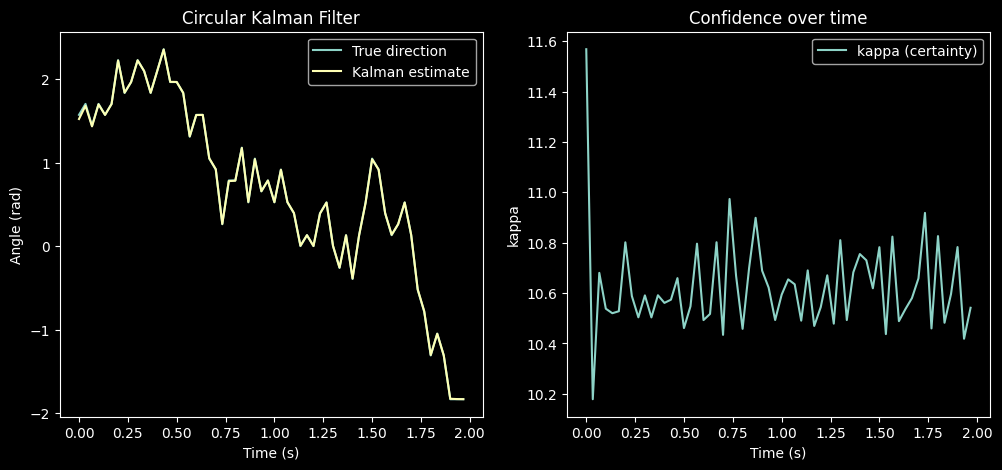

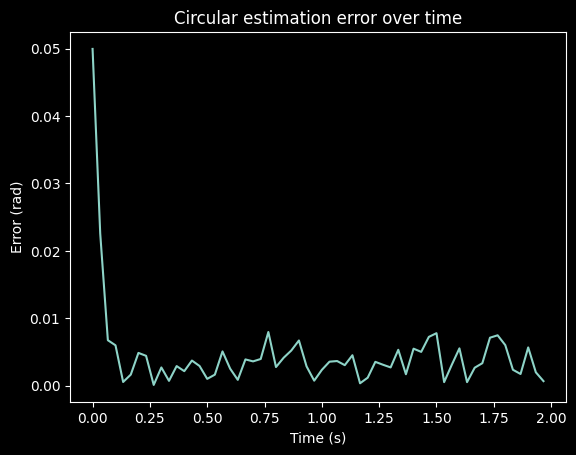

<Figure size 640x480 with 0 Axes>

In [232]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Find best circKF run (lowest error)
# --------------------------------------------------
best_error = np.inf
best_result = None
best_params = None

for params, runs in results_circKF.items():
    for run in runs:
        err = run['error']['lock_on_error']

        if err < best_error:
            best_error = err
            best_result = run
            best_params = params

print("Best circKF params:", best_params)
print("Best error:", best_error)

# --------------------------------------------------
# Extract data
# --------------------------------------------------
mu = np.asarray(best_result['mu'])
kappa = np.asarray(best_result['kappa'])

# align indexing (same issue as before)
if len(mu) == len(z) + 1:
    mu_plot = mu[1:]
    kappa_plot = kappa[1:]
else:
    mu_plot = mu
    kappa_plot = kappa

t = np.arange(len(z)) * dt

# wrap angles for clean circular plot
mu_plot = (mu_plot + np.pi) % (2*np.pi) - np.pi
z_plot = (z + np.pi) % (2*np.pi) - np.pi

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ==================================================
# 1. True vs estimate over time
# ==================================================
axes[0].plot(t, z_plot, label='True direction')
axes[0].plot(t, mu_plot, label='Kalman estimate')

axes[0].set_title('Circular Kalman Filter')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

# ==================================================
# 2. Final uncertainty (kappa trajectory or final value)
# ==================================================
axes[1].plot(t, kappa_plot, label='kappa (certainty)')
axes[1].set_title('Confidence over time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('kappa')
axes[1].legend()

##
error = np.array([
    circular_error(mu_plot[i], z[i]) for i in range(len(z))
])

plt.figure()
plt.plot(t, error)
plt.title("Circular estimation error over time")
plt.xlabel("Time (s)")
plt.ylabel("Error (rad)")
plt.show()

plt.tight_layout()
plt.show()

In [233]:
param_key = [0.5, 10.0, 0.5]
import matplotlib.pyplot as plt

## Effect of k_phi on circKF

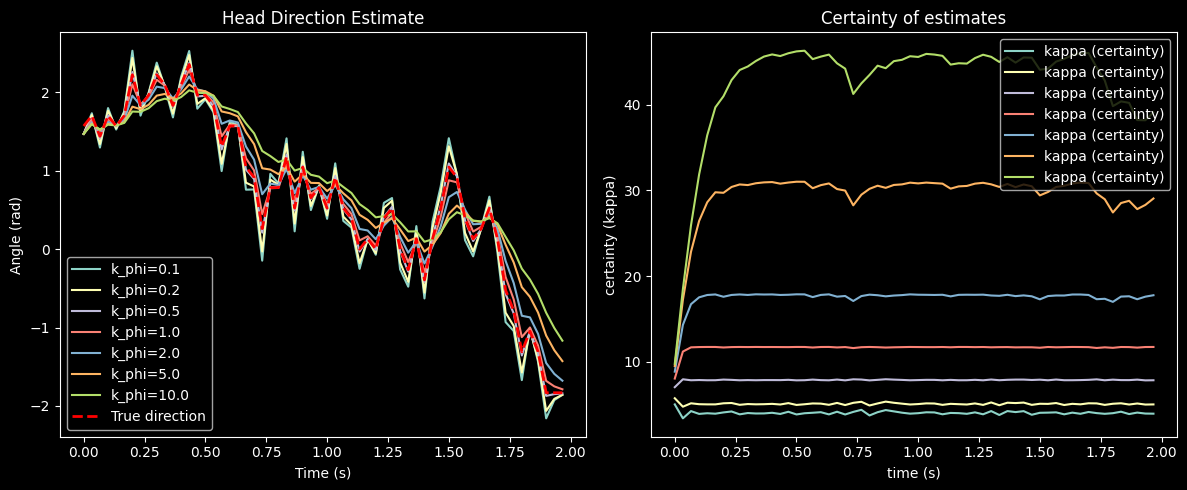

In [234]:

# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for k_phi in param_ranges['circKF']["k_phi"]:

    key = param_key.copy()
    key[0] = k_phi
    key = tuple(key)

    mu = results_circKF[key][0]['mu']
    kappa = results_circKF[key][0]['kappa']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
        kappa_plot = kappa[1:]
    else:
        mu_plot = mu
        kappa_plot = kappa

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'k_phi={k_phi}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    axes[1].plot(t, kappa_plot, label='kappa (certainty)')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')



axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Certainty of estimates')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('certainty (kappa)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Effect of k_z on CircKF

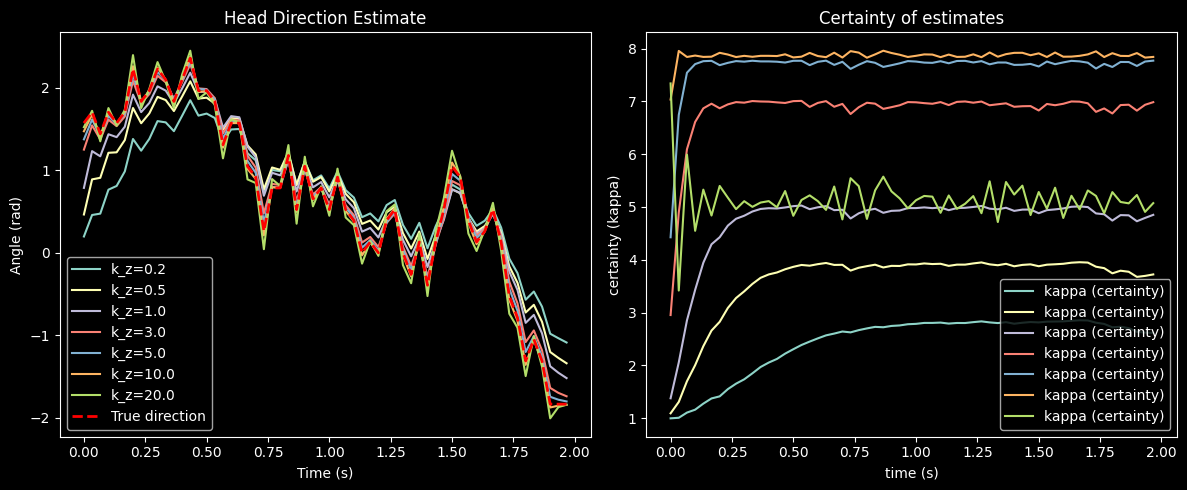

In [235]:
# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for k_z in param_ranges['circKF']["k_z"]:

    key = param_key.copy()
    key[1] = k_z
    key = tuple(key)

    mu = results_circKF[key][0]['mu']
    kappa = results_circKF[key][0]['kappa']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
        kappa_plot = kappa[1:]
    else:
        mu_plot = mu
        kappa_plot = kappa

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'k_z={k_z}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    axes[1].plot(t, kappa_plot, label='kappa (certainty)')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')



axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Certainty of estimates')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('certainty (kappa)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Effect of k_v on CircKF

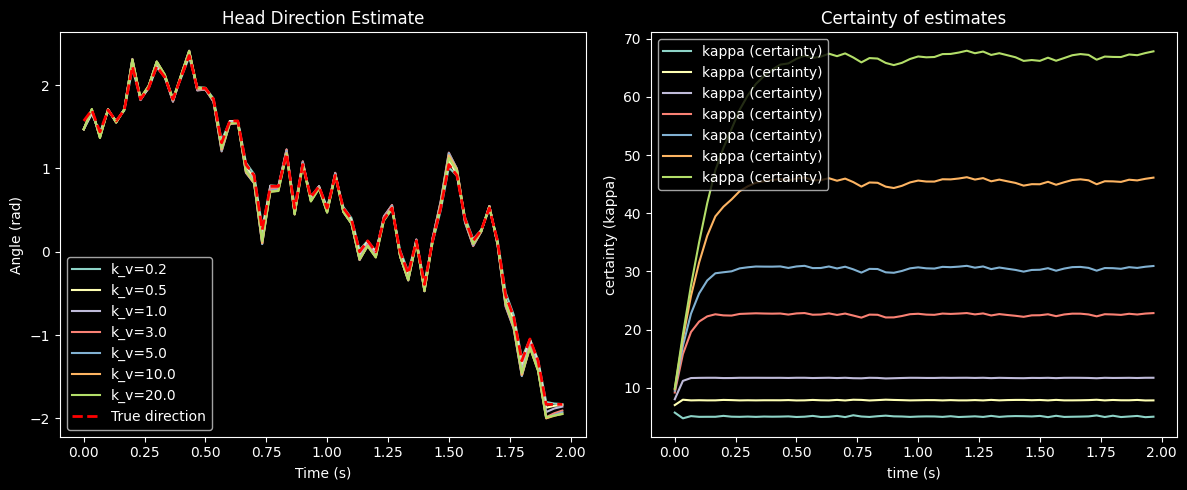

In [236]:
# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for k_v in param_ranges['circKF']["k_v"]:

    key = param_key.copy()
    key[2] = k_v
    key = tuple(key)

    mu = results_circKF[key][0]['mu']
    kappa = results_circKF[key][0]['kappa']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
        kappa_plot = kappa[1:]
    else:
        mu_plot = mu
        kappa_plot = kappa

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'k_v={k_v}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    axes[1].plot(t, kappa_plot, label='kappa (certainty)')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')



axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Certainty of estimates')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('certainty (kappa)')
axes[1].legend()

plt.tight_layout()
plt.show()

## RNN parameter sweep

Best params: (1.0, 10.0, 2.0, 0.5, 5.0, 2.0)
Best error : 0.073650353435684


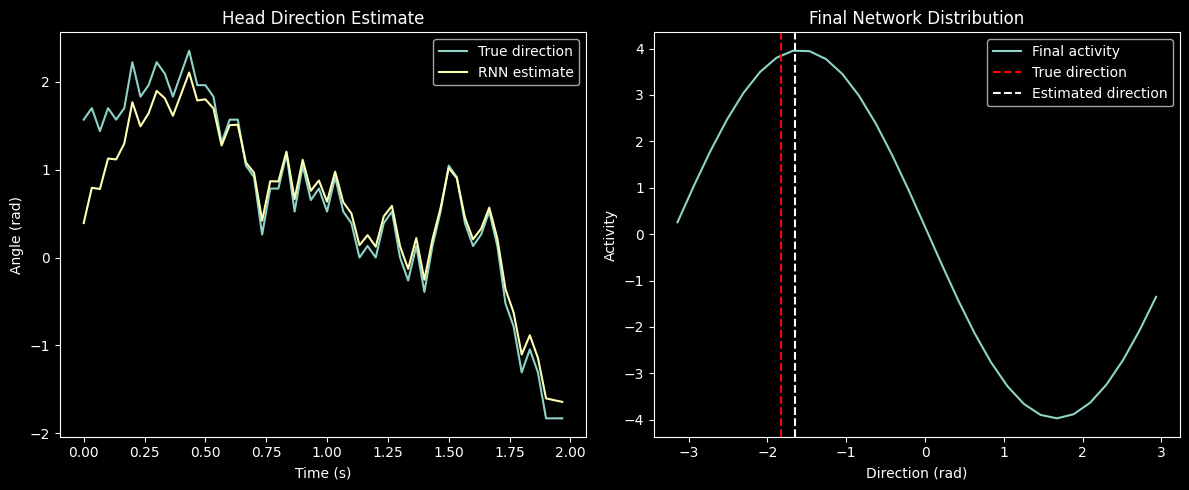

In [237]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Find best parameter set
# --------------------------------------------------
best_error = np.inf
best_result = None
best_params = None

for params, runs in results_RNN.items():
    for run in runs:
        err = run['error']['lock_on_error']

        if err < best_error:
            best_error = err
            best_result = run
            best_params = params

print("Best params:", best_params)
print("Best error :", best_error)

# --------------------------------------------------
# Extract data
# --------------------------------------------------
param_key = (1.0, 2.0, 2.0, 0.5, 0.0, 1.0)
mu = results_RNN[param_key][0]['mu']
r = results_RNN[param_key][0]['r']
#mu = np.asarray(best_result['mu'])
#r = np.asarray(best_result['r'])

# Remove initialization value if present
if len(mu) == len(z) + 1:
    mu_plot = mu[1:]
else:
    mu_plot = mu

# time axis
t = np.arange(len(z)) * dt

# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ==================================================
# Plot 1: estimate vs true direction
# ==================================================
axes[0].plot(t, z, label='True direction')
axes[0].plot(t, mu_plot, label='RNN estimate')

axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

# ==================================================
# Plot 2: final activity distribution
# ==================================================
N = len(r[-1])

theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

axes[1].plot(theta, r[-1], label='Final activity')

# true direction
true_angle = z[-1]

axes[1].axvline(
    true_angle,
    linestyle='--',
    label='True direction',
    color='r'
)

axes[1].axvline(
    mu[-1],
    linestyle='--',
    label='Estimated direction'
)

axes[1].set_title('Final Network Distribution')
axes[1].set_xlabel('Direction (rad)')
axes[1].set_ylabel('Activity')
axes[1].legend()



plt.tight_layout()
plt.show()

## effect of individual parameters

In [238]:
param_key = [1.0, 2.0, 0.5, 0.5, 0.0, 2.0]

## effect of tau

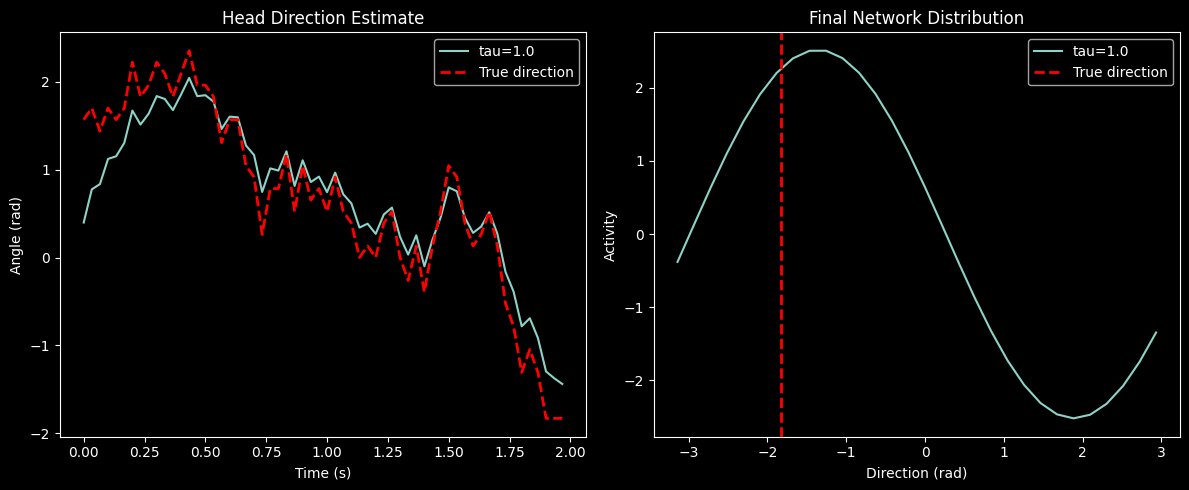

In [239]:

# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for tau in param_ranges['RNN']["tau"]:

    key = param_key.copy()
    key[0] = tau
    key = tuple(key)

    mu = results_RNN[key][0]['mu']
    r = results_RNN[key][0]['r']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
    else:
        mu_plot = mu

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'tau={tau}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    N = len(r[-1])
    theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

    axes[1].plot(theta, r[-1], label=f'tau={tau}')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')

# Plot final true angle only once
axes[1].axvline(
    z[-1],
    color='r',
    linestyle='--',
    linewidth=2,
    label='True direction'
)

axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Final Network Distribution')
axes[1].set_xlabel('Direction (rad)')
axes[1].set_ylabel('Activity')
axes[1].legend()

plt.tight_layout()
plt.show()

## effect of Kappa_z

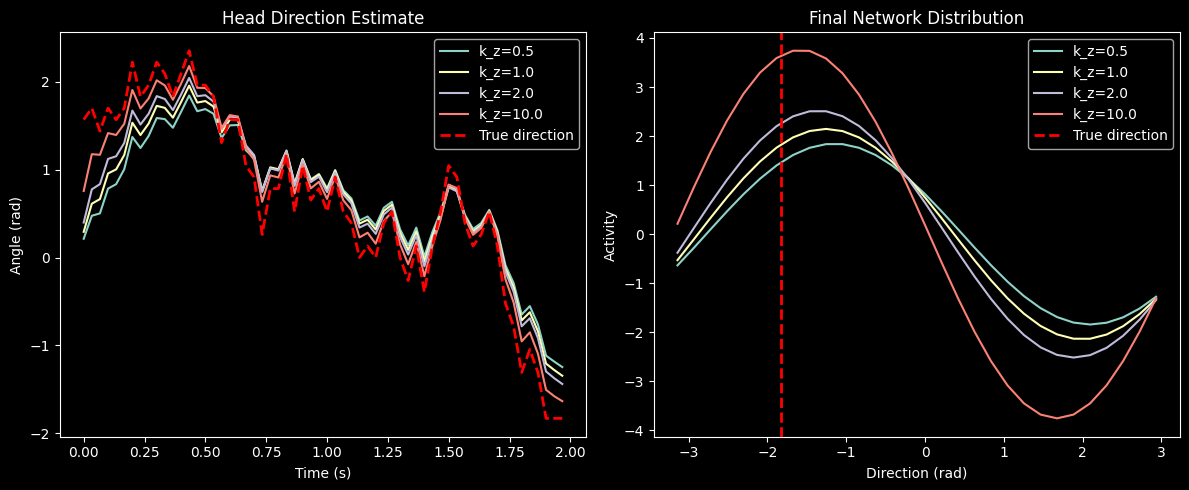

In [240]:
# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for k_z in param_ranges['RNN']["k_z"]:

    key = param_key.copy()
    key[1] = k_z
    key = tuple(key)

    mu = results_RNN[key][0]['mu']
    r = results_RNN[key][0]['r']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
    else:
        mu_plot = mu

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'k_z={k_z}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    N = len(r[-1])
    theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

    axes[1].plot(theta, r[-1], label=f'k_z={k_z}')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')

# Plot final true angle only once
axes[1].axvline(
    z[-1],
    color='r',
    linestyle='--',
    linewidth=2,
    label='True direction'
)

axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Final Network Distribution')
axes[1].set_xlabel('Direction (rad)')
axes[1].set_ylabel('Activity')
axes[1].legend()

plt.tight_layout()
plt.show()

## Effect of k_v

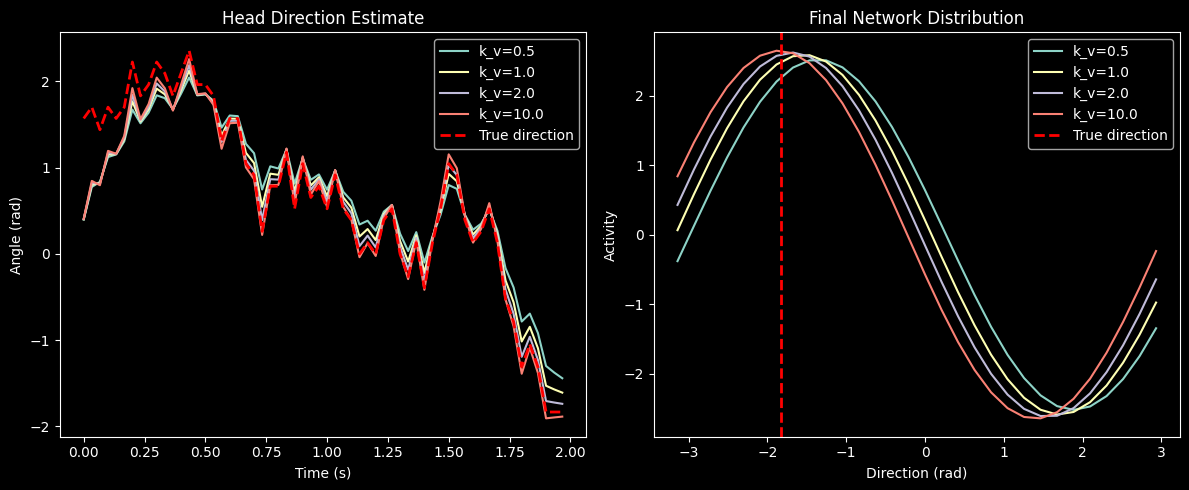

In [241]:
# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for k_v in param_ranges['RNN']["k_v"]:

    key = param_key.copy()
    key[2] = k_v
    key = tuple(key)

    mu = results_RNN[key][0]['mu']
    r = results_RNN[key][0]['r']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
    else:
        mu_plot = mu

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'k_v={k_v}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    N = len(r[-1])
    theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

    axes[1].plot(theta, r[-1], label=f'k_v={k_v}')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')

# Plot final true angle only once
axes[1].axvline(
    z[-1],
    color='r',
    linestyle='--',
    linewidth=2,
    label='True direction'
)

axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Final Network Distribution')
axes[1].set_xlabel('Direction (rad)')
axes[1].set_ylabel('Activity')
axes[1].legend()

plt.tight_layout()
plt.show()

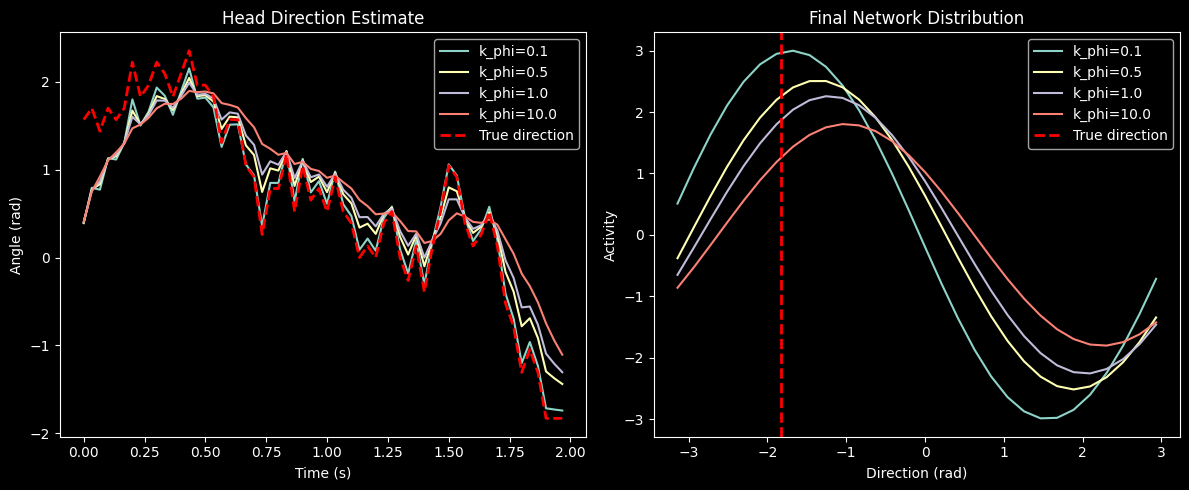

In [242]:
# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for k_phi in param_ranges['RNN']["k_phi"]:

    key = param_key.copy()
    key[3] = k_phi
    key = tuple(key)

    mu = results_RNN[key][0]['mu']
    r = results_RNN[key][0]['r']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
    else:
        mu_plot = mu

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'k_phi={k_phi}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    N = len(r[-1])
    theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

    axes[1].plot(theta, r[-1], label=f'k_phi={k_phi}')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')

# Plot final true angle only once
axes[1].axvline(
    z[-1],
    color='r',
    linestyle='--',
    linewidth=2,
    label='True direction'
)

axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Final Network Distribution')
axes[1].set_xlabel('Direction (rad)')
axes[1].set_ylabel('Activity')
axes[1].legend()

plt.tight_layout()
plt.show()

## Effect of w_const

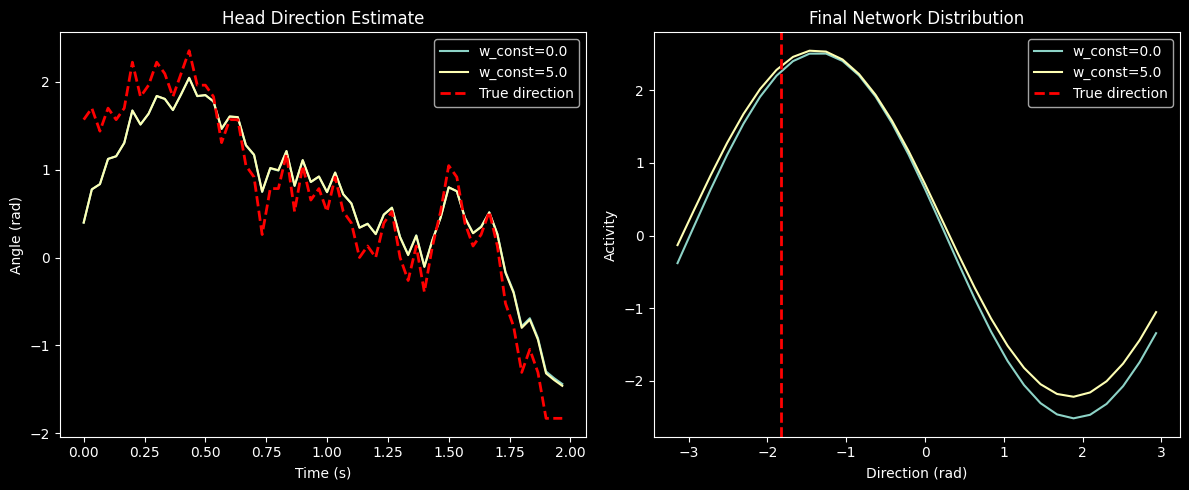

In [243]:
# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for w_const in param_ranges['RNN']["w_const"]:

    key = param_key.copy()
    key[4] = w_const
    key = tuple(key)

    mu = results_RNN[key][0]['mu']
    r = results_RNN[key][0]['r']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
    else:
        mu_plot = mu

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'w_const={w_const}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    N = len(r[-1])
    theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

    axes[1].plot(theta, r[-1], label=f'w_const={w_const}')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')

# Plot final true angle only once
axes[1].axvline(
    z[-1],
    color='r',
    linestyle='--',
    linewidth=2,
    label='True direction'
)

axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Final Network Distribution')
axes[1].set_xlabel('Direction (rad)')
axes[1].set_ylabel('Activity')
axes[1].legend()

plt.tight_layout()
plt.show()

## effect of w_quad

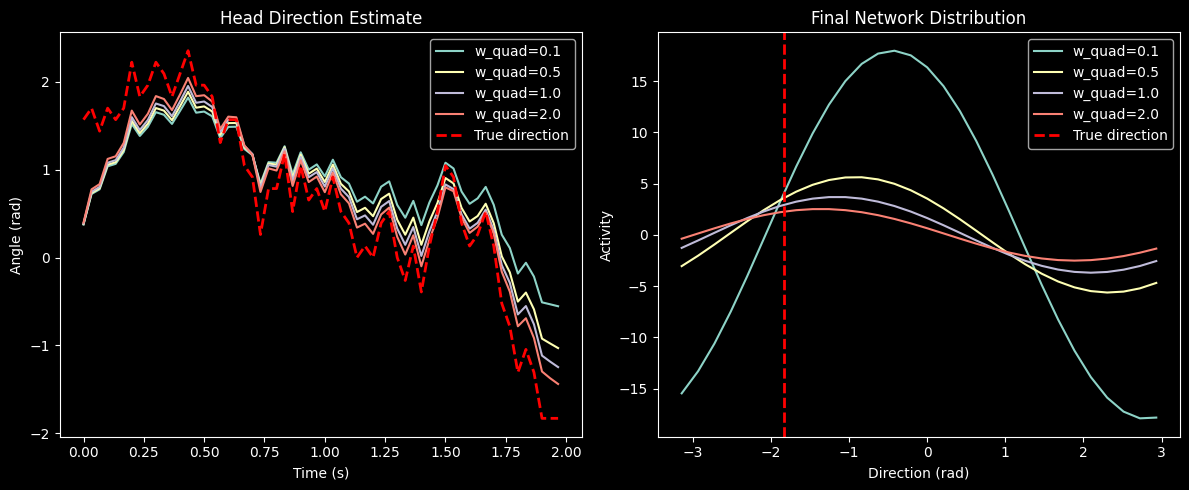

In [244]:
# --------------------------------------------------
# Create figure once
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# time axis
t = np.arange(len(z)) * dt

for w_quad in param_ranges['RNN']["w_quad"]:

    key = param_key.copy()
    key[5] = w_quad
    key = tuple(key)

    mu = results_RNN[key][0]['mu']
    r = results_RNN[key][0]['r']

    # Remove initialization value if present
    if len(mu) == len(z) + 1:
        mu_plot = mu[1:]
    else:
        mu_plot = mu

    # ==========================================
    # Plot 1: estimate vs true direction
    # ==========================================
    axes[0].plot(t, mu_plot, label=f'w_quad={w_quad}')

    # ==========================================
    # Plot 2: final activity distribution
    # ==========================================
    N = len(r[-1])
    theta = np.linspace(-np.pi, np.pi, N, endpoint=False)

    axes[1].plot(theta, r[-1], label=f'w_quad={w_quad}')

# Plot true direction only once
axes[0].plot(t, z, 'r--', linewidth=2, label='True direction')

# Plot final true angle only once
axes[1].axvline(
    z[-1],
    color='r',
    linestyle='--',
    linewidth=2,
    label='True direction'
)

axes[0].set_title('Head Direction Estimate')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].legend()

axes[1].set_title('Final Network Distribution')
axes[1].set_xlabel('Direction (rad)')
axes[1].set_ylabel('Activity')
axes[1].legend()

plt.tight_layout()
plt.show()